# 4 · Preference Latent Space — *Mass-Mean-Probe* (PTO only)  `[TRAINING]`

Inside PTO's training signal: what, in words, the (chosen − rejected) preference pushes the policy
toward, and how that target moves across iterations and between K=0 and K=5. Per iteration the unit
**preference direction** = normalized mean(chosen − rejected) embedding; projecting words / MI-concepts
onto it reads out the preference. PTO-only by construction (GRPO has no pairs; its signal is in `2`).

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import eda_analysis
from eda_analysis import stats, behavior, training, pref, figures, plots

# ── EDA config — edit these flat globals to control the whole notebook ─────────
cfg = eda_analysis.EdaConfig(
    methods=None, ks=None, arm_labels=None,        # arm filter (None = all on disk)
    metrics=None, selection="all", warmth_only=False,  # metric subset / cross-model selection
    focus_arms=None, focus_metric="Q1Q2",          # default arms/metric for overlay & contrast figs
    panel=None, ncols=None, score_ylim=None, share_y=False,  # plot scales (None = inherit)
    export_group="preference",                         # results/<figures|tables>/preference/  ·  figs=PNG, tables=md+xlsx
)
S = eda_analysis.notebook_setup(cfg)
FOCUS = cfg.focus_arms or sorted(S.SCORES.arm.unique())   # arms to show in overlay/contrast figures

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 11), ('GRPO_LA5', 2)]
scores_long: (32851, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
metrics: ['Q1Q2', 'WAI-SR', 'CSQ-8', 'MI-SAT', 'MITI', 'PCT', 'MICI', 'Q1', 'Q2'] | selection: all
exports -> c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results  [group: preference]


## 0 · PTO arms with preference data

In [2]:
PTO_ARMS = [a for a in S.ARMS if a.method == "PTO"
            and (cfg.focus_arms is None or a.label in cfg.focus_arms)
            and len(training.load_pref_pairs([a]))]
print("PTO arms analysed:", [a.label for a in PTO_ARMS])

PTO arms analysed: ['PTO_LA0', 'PTO_LA5']


## 1 · Per-arm preference, iteration by iteration  `[TRAINING]`
**Purpose.** Per PTO arm: probe quality (does the direction separate the pairs? wins > 0.5) → pooled
word ranking → per-iteration word drift (heatmap + top-words table) → **direction drift in 2D** +
consecutive cosine → **learned vs unlearned words** → MI-concept drift + a first→last read-out.


################  PTO_LA0  ################
[probe] wins_correct should be > 0.5 for a real preference axis:


,train_iter,n,wins_correct,mean_gap,mean_margin
0,1,782,0.6509,0.0517,0.3217
1,2,618,0.6553,0.0629,0.2988
2,3,620,0.6097,0.0493,0.2946
3,4,536,0.6511,0.0510,0.2690
4,5,483,0.6605,0.0493,0.2812
5,6,475,0.6926,0.0605,0.2673
6,7,400,0.6825,0.0513,0.2718
7,8,379,0.6623,0.0629,0.2491
8,9,361,0.7175,0.0594,0.2657
9,10,281,0.7082,0.0624,0.2667


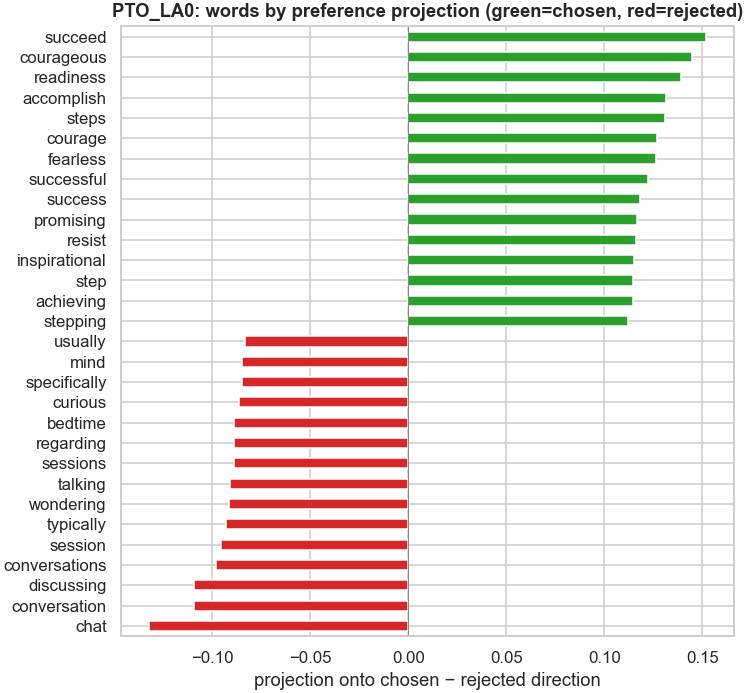

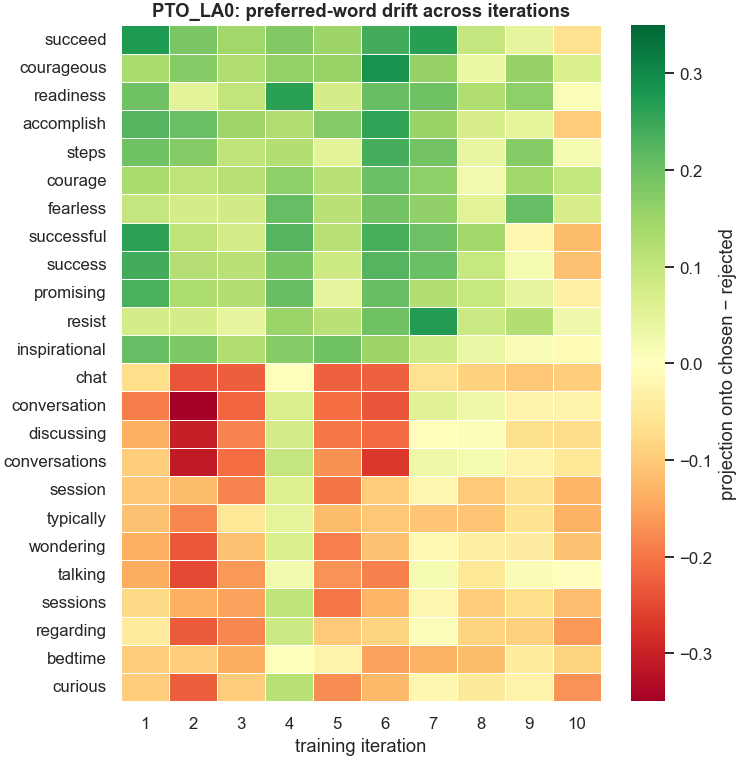

,train_iter,chosen_top,rejected_top
0,1,"mentors, approaches, guiding, guides, strategi...","conversation, anyway, trauma, talk, meant, wor..."
1,2,"motivate, motivating, motivates, motivation, a...","conversation, conversations, discussing, talke..."
2,3,"aspirations, cravings, craving, optimistic, go...","sure, check, request, alright, works, contact,..."
3,4,"hesitant, willing, willingness, convinced, acc...","exercising, obesity, exhale, calorie, weights,..."
4,5,"motivate, motivating, frustration, impulsive, ...","health, weight, chat, diet, healthier, pounds,..."
5,6,"milestone, courageous, milestones, successes, ...","conversations, conversation, chat, discussing,..."
6,7,"fail, resist, succeed, quit, strong, failed, d...","calendar, mealtimes, meals, regularly, monthly..."
7,8,"hesitate, congratulations, rejection, hope, de...","mindfulness, alleviate, yoga, meditation, medi..."
8,9,"intervention, interventions, assistance, fearl...","savoring, celebrations, cravings, enjoyment, c..."
9,10,"quit, quitters, smoker, quitline, bravery, qui...","perception, perceive, desire, celebrations, de..."


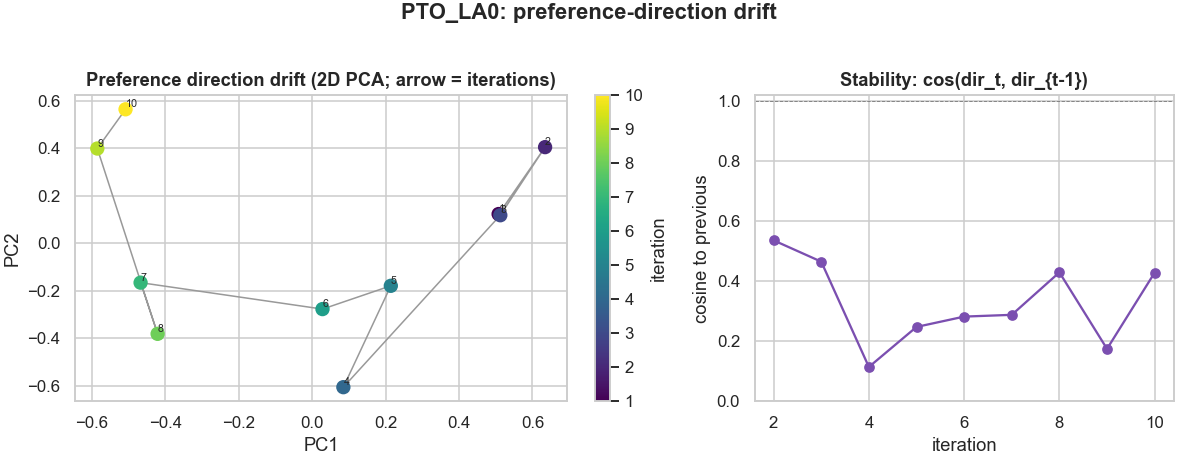

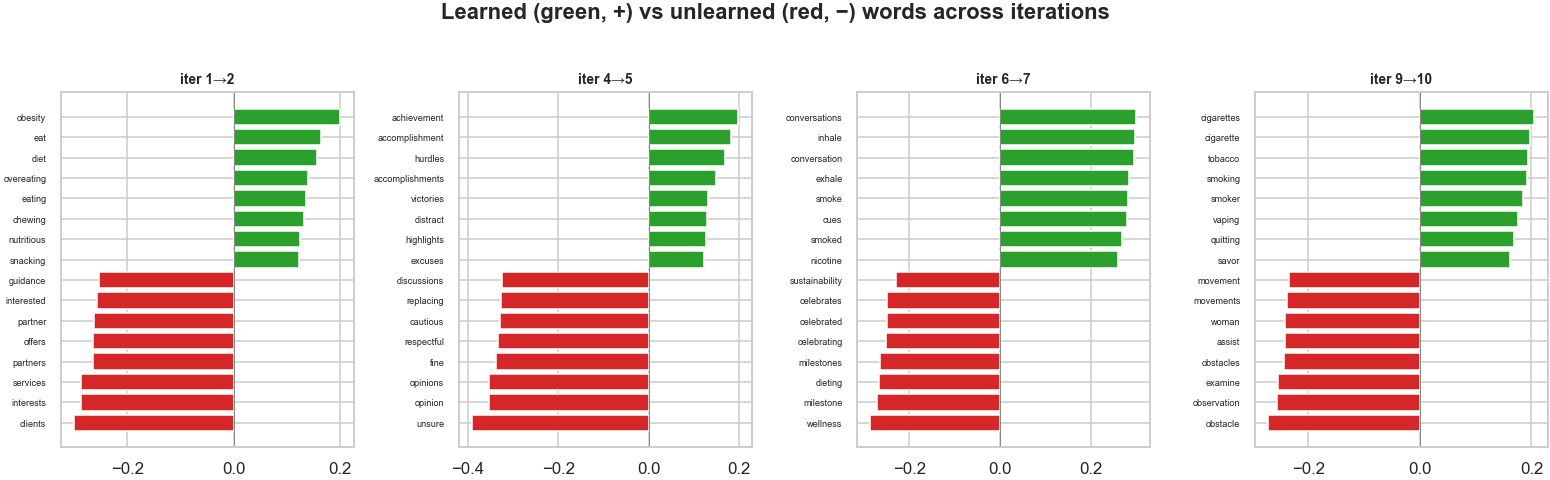

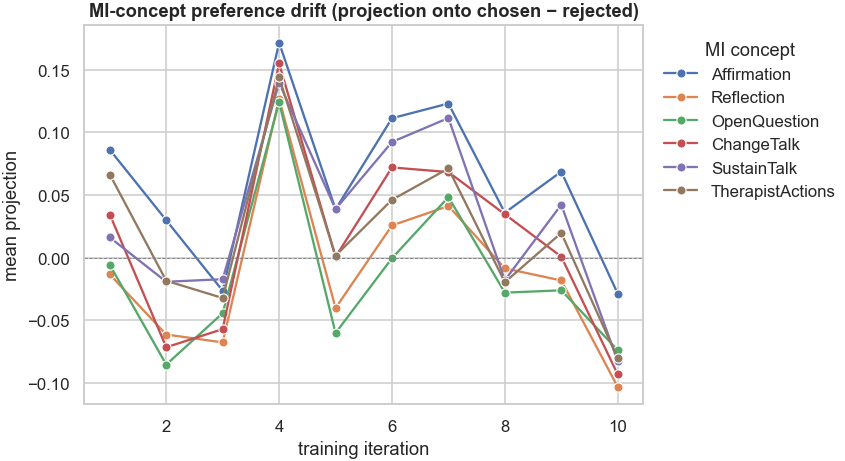

[MI-concept shift iter 1->10; + = MORE preferred over training]:
   OpenQuestion     -0.006 -> -0.074   (Δ -0.068)
   Reflection       -0.014 -> -0.103   (Δ -0.090)
   SustainTalk      +0.016 -> -0.083   (Δ -0.099)
   Affirmation      +0.086 -> -0.029   (Δ -0.115)
   ChangeTalk       +0.034 -> -0.093   (Δ -0.128)
   TherapistActions +0.066 -> -0.081   (Δ -0.147)

################  PTO_LA5  ################
[probe] wins_correct should be > 0.5 for a real preference axis:


,train_iter,n,wins_correct,mean_gap,mean_margin
0,1,832,0.6430,0.0817,0.4512
1,2,778,0.6093,0.0725,0.4614
2,3,768,0.6615,0.0748,0.4705
3,4,563,0.6199,0.0566,0.4260
4,5,432,0.6551,0.0561,0.4086


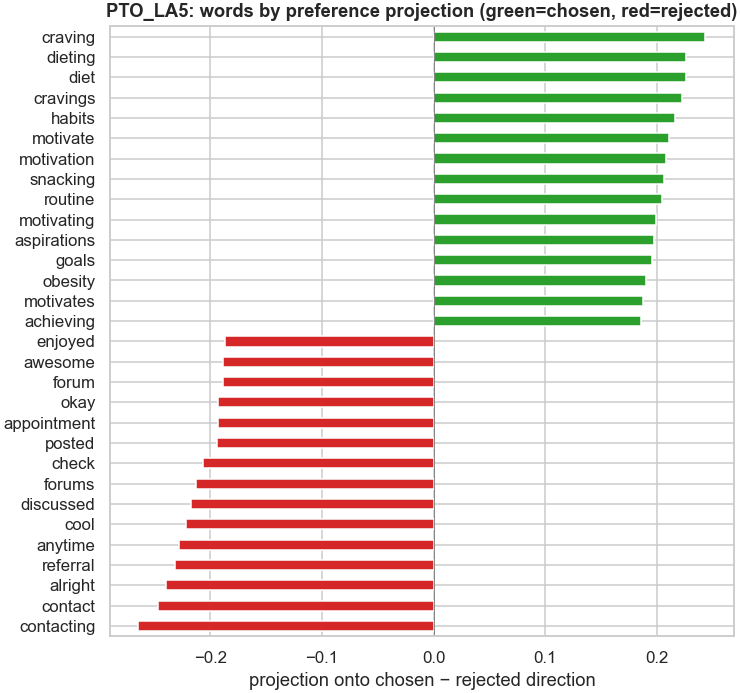

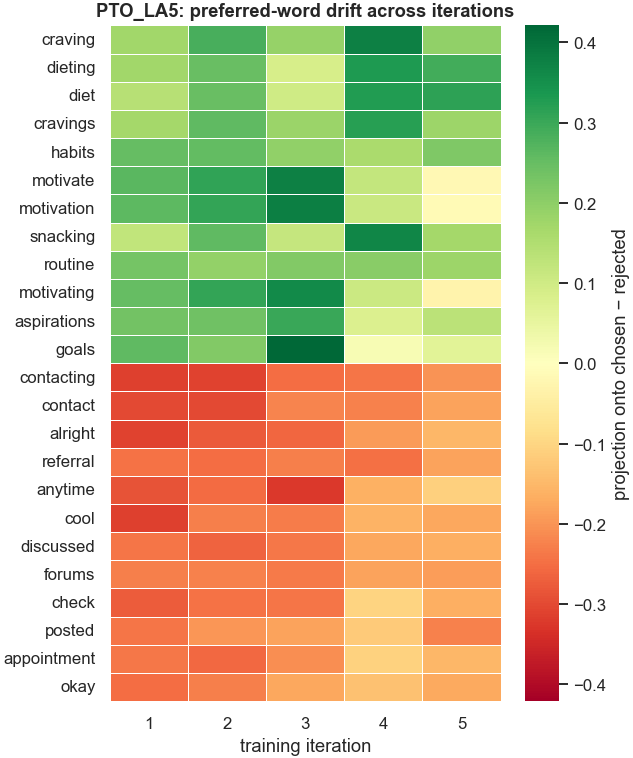

,train_iter,chosen_top,rejected_top
0,1,"motivate, motivation, goals, habits, motivatin...","cool, contacting, alright, contact, fine, anyt..."
1,2,"motivate, motivation, motivating, motivates, c...","contacting, contact, alright, consultation, di..."
2,3,"goals, motivation, motivate, motivating, motiv...","anytime, alright, registered, enjoyed, contact..."
3,4,"craving, snacking, eating, eat, dieting, appet...","counselors, referral, contacting, therapists, ..."
4,5,"diet, dieting, dietary, diets, healthy, health...","ended, finished, encounter, busy, encountered,..."


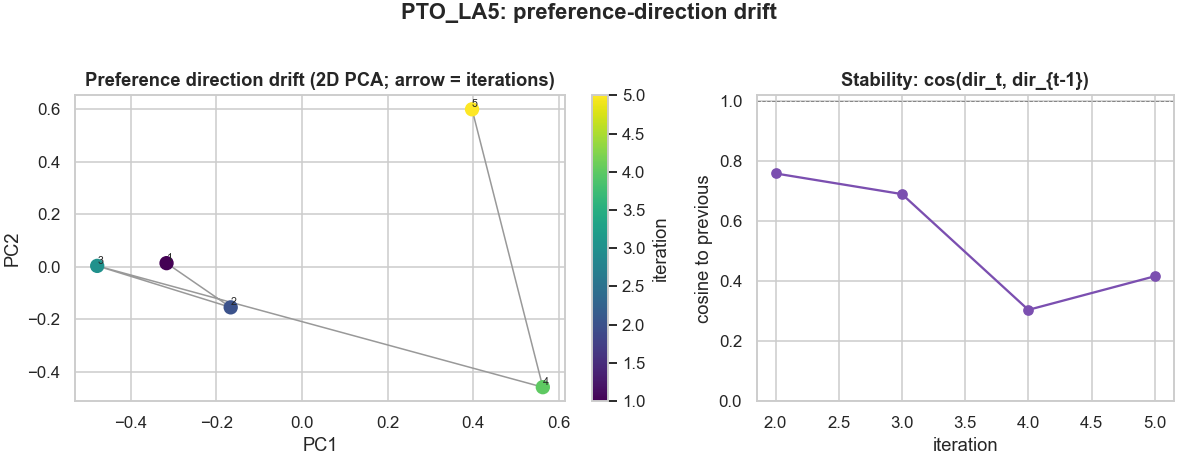

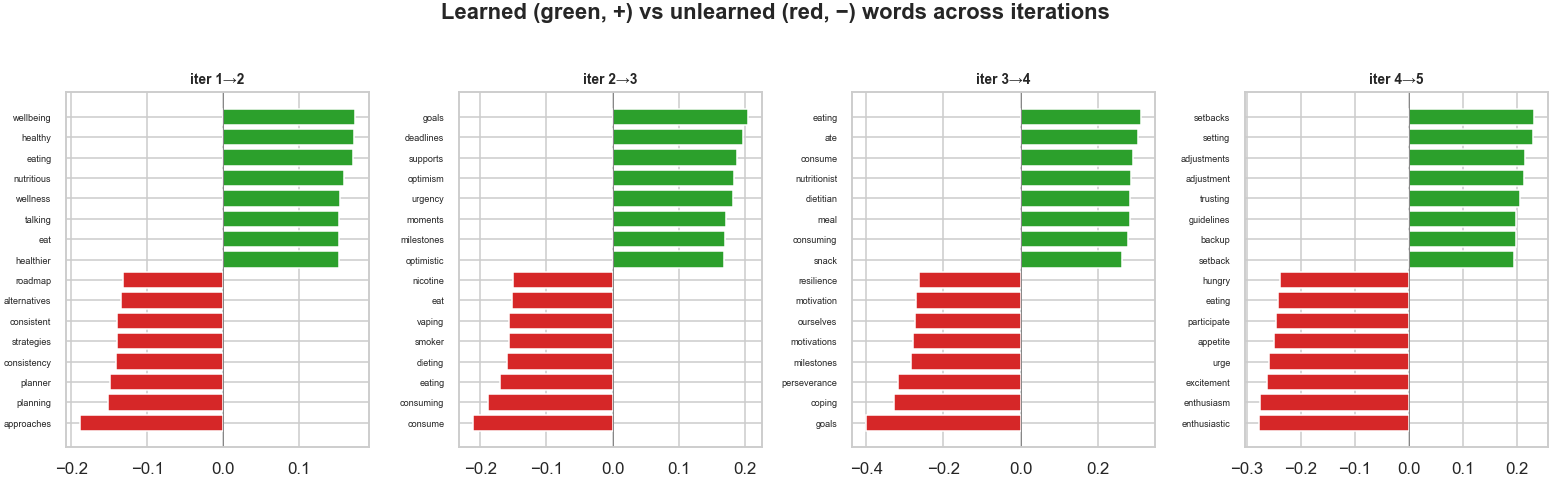

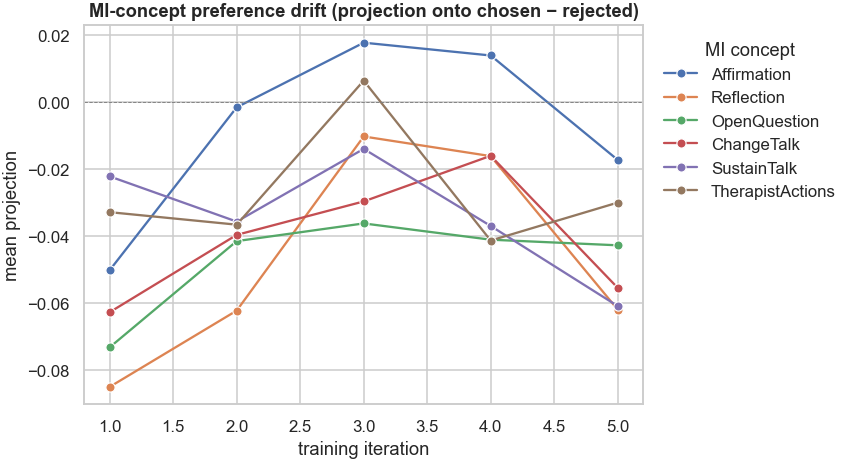

[MI-concept shift iter 1->5; + = MORE preferred over training]:
   Affirmation      -0.050 -> -0.017   (Δ +0.033)
   OpenQuestion     -0.073 -> -0.043   (Δ +0.030)
   Reflection       -0.085 -> -0.062   (Δ +0.023)
   ChangeTalk       -0.063 -> -0.055   (Δ +0.007)
   TherapistActions -0.033 -> -0.030   (Δ +0.003)
   SustainTalk      -0.022 -> -0.061   (Δ -0.039)


In [3]:
RESULTS = {}   # arm -> {DIRS, CAT} for the K0-vs-K5 comparison in §2

def analyze_pref(arm):
    PAIRS = pref.add_text_features(training.load_pref_pairs([arm]))
    if PAIRS.empty:
        print(f"{arm.label}: no pairs."); return
    EMB = pref.embed_pairs(PAIRS)
    DIRS = pref.preference_direction_by_iter(EMB)
    print(f"\n################  {arm.label}  ################")
    PQ = pref.probe_quality_by_iter(EMB, DIRS)
    print("[probe] wins_correct should be > 0.5 for a real preference axis:"); display(PQ.round(4))
    eda_analysis.save_table(PQ.round(4), f"{arm.label}_pref_probe_quality", caption=f"{arm.label} preference-probe quality per iteration (wins_correct, gap, margin).")
    words, wmat = pref.embed_vocab(pref.build_vocab(PAIRS, top_n=3000)); WP = pref.word_projection(words, wmat, DIRS)
    # overall preference + per-iteration word drift
    fig = pref.pref_word_ranking(WP, title=f"{arm.label}: words by preference projection (green=chosen, red=rejected)")
    if fig: eda_analysis.save_fig(fig, f"{arm.label}_pref_word_ranking", caption=f"{arm.label} top chosen/rejected-aligned words (Mass Mean Probe, pooled over iters)."); plt.show()
    fig = pref.pref_word_drift_heatmap(WP, title=f"{arm.label}: preferred-word drift across iterations")
    if fig: eda_analysis.save_fig(fig, f"{arm.label}_pref_word_drift", caption=f"{arm.label} per-iteration projection of the top chosen-/rejected-aligned words (drift)."); plt.show()
    display(pref.top_words_by_iter(WP, k=8))
    # direction drift (vectors) + learned/unlearned words
    fig = pref.plot_direction_drift(pref.preference_direction_drift(DIRS), title=f"{arm.label}: preference-direction drift")
    if fig: eda_analysis.save_fig(fig, f"{arm.label}_pref_direction_drift", caption=f"{arm.label} preference direction in 2D PCA + consecutive cosine (how the preferred axis re-orients across iterations)."); plt.show()
    fig = pref.plot_learn_unlearn(pref.learn_unlearn_words(WP, k=8))
    if fig: eda_analysis.save_fig(fig, f"{arm.label}_pref_learn_unlearn", caption=f"{arm.label} words most newly preferred (learned) vs dropped (unlearned) across iteration transitions."); plt.show()
    # MI-concept drift + first->last read-out
    CAT = pref.category_projection(DIRS)
    if not CAT.empty:
        fig = pref.plot_category_drift(CAT)
        if fig: eda_analysis.save_fig(fig, f"{arm.label}_pref_category_drift", caption=f"{arm.label} MI-concept word groups projected onto the chosen-rejected direction per iteration."); plt.show()
        eda_analysis.save_table(CAT.round(4), f"{arm.label}_pref_MI_concepts", caption=f"{arm.label} MI-concept projection onto the preference direction per iteration.")
        wide = CAT.pivot_table(index="category", columns="train_iter", values="score")
        f0, fl = wide.columns.min(), wide.columns.max()
        print(f"[MI-concept shift iter {f0}->{fl}; + = MORE preferred over training]:")
        for cat, d in (wide[fl] - wide[f0]).sort_values(ascending=False).items():
            print(f"   {cat:<16} {wide.loc[cat, f0]:+.3f} -> {wide.loc[cat, fl]:+.3f}   (Δ {d:+.3f})")
    RESULTS[arm.label] = {"DIRS": DIRS, "CAT": CAT}

for arm in PTO_ARMS:
    analyze_pref(arm)
if not PTO_ARMS:
    print("No PTO arm with preference pairs scored yet.")

## 2 · Does look-ahead change *what* is preferred? K=0 vs K=5  `[TRAINING]`
**Purpose.** Overlay PTO_LA0 vs PTO_LA5 MI-concept preference across iterations, and the cosine between
their per-iteration directions. **Read:** diverging curves / low cosine = look-ahead steers the
preference toward different language. (Preliminary while the LA5 arm is thin.)

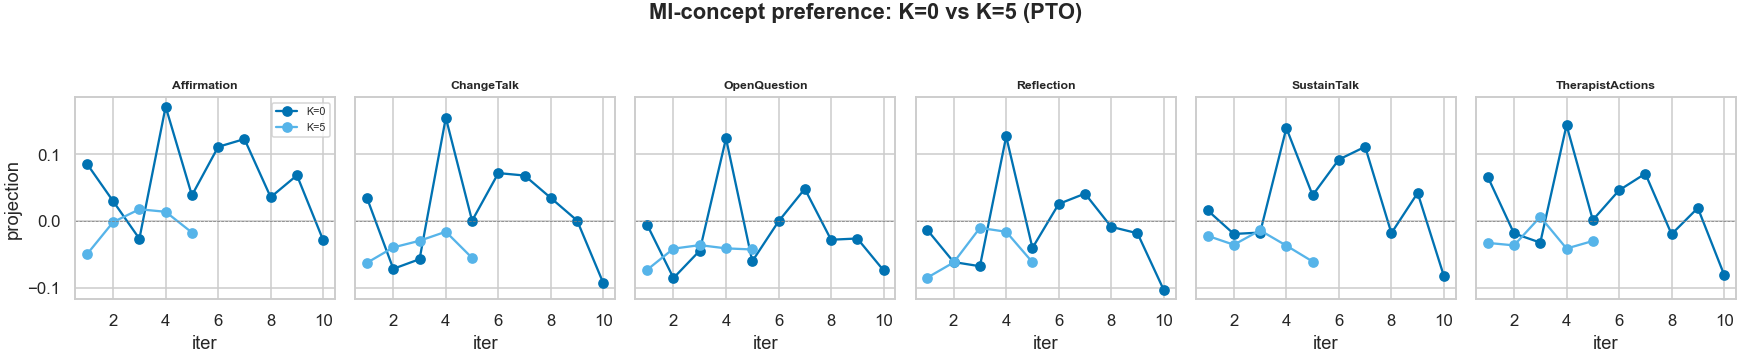

cos(dir_K0, dir_K5) at matched iters: {1: 0.315, 2: 0.516, 3: 0.483, 4: -0.004, 5: -0.071}


In [4]:
if {"PTO_LA0", "PTO_LA5"} <= set(RESULTS):
    cat0, cat5 = RESULTS["PTO_LA0"]["CAT"], RESULTS["PTO_LA5"]["CAT"]
    cats = sorted(set(cat0.category) & set(cat5.category))
    fig, axes = plt.subplots(1, len(cats), figsize=(2.7 * len(cats), 3.2), squeeze=False, sharey=True)
    for ax, c in zip(axes.flat, cats):
        for lab, cat, col in [("K=0", cat0, "#0072B2"), ("K=5", cat5, "#56B4E9")]:
            d = cat[cat.category == c]
            ax.plot(d.train_iter, d.score, marker="o", label=lab, color=col)
        ax.axhline(0, color="grey", lw=0.5, ls="--"); ax.set_title(c, fontsize=8); ax.set_xlabel("iter")
    axes.flat[0].legend(fontsize=7); axes.flat[0].set_ylabel("projection")
    fig.suptitle("MI-concept preference: K=0 vs K=5 (PTO)", y=1.05, fontweight="bold"); fig.tight_layout()
    eda_analysis.save_fig(fig, "pref_category_K0_vs_K5", caption="PTO MI-concept preference projection across iterations, K=0 vs K=5 — does look-ahead change what the policy prefers?"); plt.show()
    d0, d5 = RESULTS["PTO_LA0"]["DIRS"], RESULTS["PTO_LA5"]["DIRS"]
    common = sorted(set(d0) & set(d5))
    if common:
        print("cos(dir_K0, dir_K5) at matched iters:", {i: round(float(d0[i] @ d5[i]), 3) for i in common})
else:
    print("Need both PTO_LA0 and PTO_LA5 with pref pairs for the K comparison.")

## 3 · How to read this notebook
- **Probe real?** `wins_correct` ≫ 0.5 means the mean(chosen−rejected) direction genuinely separates the pairs.
- **What / how it drifts:** the word ranking + drift heatmap + learn/unlearn + MI-concept read-out test whether **affirmation/achievement** language becomes more preferred while **questions/reflection** fade — the latent-space signature of the behaviour drift in `1`.
- **Direction drift:** a low consecutive cosine means the preferred axis is re-orienting iteration to iteration, not just intensifying.
- **Caveat:** this is the **[TRAINING]** signal (what DPO optimises), not the eval — whether the shift is *good* is an eval/behaviour question (eval `1` / stats `5`).